## <span style="color:#db7d60">Purpose</span>

The goal of this notebook is to test more lr schedules for the models.

In [19]:
%load_ext autoreload
%autoreload 2

import sys
import time
import json
import pickle
from collections import Counter, defaultdict
from types import SimpleNamespace
from itertools import islice
from pathlib import Path
# Math
import math
import numpy as np
import pandas as pd
from numba import njit, float64, types
from numba.experimental import jitclass
from numba.typed import Dict
from scipy.signal import savgol_filter
from numerize import numerize
# Plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter, FuncFormatter, MaxNLocator
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

from particle import Particle
import vector
import jetnet
import jetnet.evaluation

# pUtil needs to be loaded from the root directory
parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir))

# particleGPT
import pUtil
import data_manager
from analysis_common import *
import analysis_v2 as analv2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
training_status_filepath = parent_dir / 'scripts' / 'experiment_11' / 'exp11_lrschedules_2' / 'lr_schedules_training_status.json'
config_dir = parent_dir / 'config' / 'exp11_lrschedules_2'

with open(training_status_filepath, 'r') as f:
    training_status = json.load(f)

mns = []
for tp, data in training_status.items():
    for inf in data:
        mns.append(inf['model_name'])

model_names = []
for mn in mns:
    training_log_filename = pUtil.get_training_dir(mn) / "train_log_1.jsonl"
    if training_log_filename.exists():
        model_names.append(mn)

In [21]:
model_names = model_names
model_labels = model_names

df = analv2.tables.get_default_df(model_names)
df["compute"] = df["num_params"] * df["batch_size"] * df["iters_saved"]
display(df[analv2.tables.model_config_columns])

# ---- Best model for each lr_decay_iters ----
idx_decay_iters = df.groupby("lr_decay_iters")["min_saved_val_loss"].idxmin()
best_model_names_decay_iters = df.loc[idx_decay_iters, "model_name"].tolist()

# ---- Best model for each min_lr ----
idx_min_lr = df.groupby("min_lr")["min_saved_val_loss"].idxmin()
best_model_names_min_lr = df.loc[idx_min_lr, "model_name"].tolist()

# ---- Best model for each num_params ----
idx_num_params = df.groupby("num_params")["min_saved_val_loss"].idxmin()
best_model_names_num_params = df.loc[idx_num_params, "model_name"].tolist()

print("Best per lr_decay_iters:")
print(best_model_names_decay_iters)

print("\nBest per min_lr:")
print(best_model_names_min_lr)

print("\nBest per num_params:")
print(best_model_names_num_params)

,batch_size,block_size,learning_rate,min_lr,lr_warmup_iters,lr_decay_iters,lr_scheduler,n_layer,n_head,n_embd,num_params
0,32,166,0.001,0.00050,27,200.0,cosine_annealing_with_warmup,4,2,512,20148224
1,32,166,0.001,0.00010,27,200.0,cosine_annealing_with_warmup,4,2,512,20148224
2,32,166,0.001,0.00005,27,200.0,cosine_annealing_with_warmup,4,2,512,20148224
3,32,166,0.001,0.00001,27,200.0,cosine_annealing_with_warmup,4,2,512,20148224
4,32,166,0.001,0.00050,27,400.0,cosine_annealing_with_warmup,4,2,512,20148224
...,...,...,...,...,...,...,...,...,...,...,...
78,32,166,0.001,0.00010,27,800.0,cosine_annealing_with_warmup,32,128,512,108257280
79,32,166,0.001,0.00005,27,800.0,cosine_annealing_with_warmup,32,128,512,108257280
80,32,166,0.001,0.00001,27,800.0,cosine_annealing_with_warmup,32,128,512,108257280
81,32,166,0.001,0.00050,27,1000.0,cosine_annealing_with_warmup,32,128,512,108257280


Best per lr_decay_iters:
['model_exp11_lrschedules_2_100k_lr2_tp6', 'model_exp11_lrschedules_2_100k_lr6_tp6', 'model_exp11_lrschedules_2_100k_lr10_tp6', 'model_exp11_lrschedules_2_100k_lr14_tp3', 'model_exp11_lrschedules_2_100k_lr19_tp4', 'model_exp11_lrschedules_2_100k_lr23_tp4']

Best per min_lr:
['model_exp11_lrschedules_2_100k_lr11_tp6', 'model_exp11_lrschedules_2_100k_lr6_tp6', 'model_exp11_lrschedules_2_100k_lr5_tp4', 'model_exp11_lrschedules_2_100k_lr8_tp4']

Best per num_params:
['model_exp11_lrschedules_2_100k_lr10_tp1', 'model_exp11_lrschedules_2_100k_lr6_tp6', 'model_exp11_lrschedules_2_100k_lr5_tp4', 'model_exp11_lrschedules_2_100k_lr14_tp3']


In [22]:
disp_df = df[['model_name', 'iters_saved', 'min_saved_train_loss', 'min_saved_val_loss', 'num_train_tokens', 'num_params', 'lr_decay_iters', 'lr_warmup_iters', 'min_lr']].copy()
display(disp_df.sort_values(by=['num_params', 'min_saved_val_loss'], ascending=True)
    .style.format({"num_train_tokens": "{:,}", "num_params": "{:,}" , "compute": "{:,}"}))

,model_name,iters_saved,min_saved_train_loss,min_saved_val_loss,num_train_tokens,num_params,lr_decay_iters,lr_warmup_iters,min_lr
10,model_exp11_lrschedules_2_100k_lr10_tp1,1611,4.638991,4.714789,"16,600,000","20,148,224",600.000000,27,0.000050
11,model_exp11_lrschedules_2_100k_lr11_tp1,2439,4.671709,4.716472,"16,600,000","20,148,224",600.000000,27,0.000010
5,model_exp11_lrschedules_2_100k_lr5_tp1,1665,4.652725,4.719191,"16,600,000","20,148,224",400.000000,27,0.000100
6,model_exp11_lrschedules_2_100k_lr6_tp1,1575,4.683803,4.719812,"16,600,000","20,148,224",400.000000,27,0.000050
2,model_exp11_lrschedules_2_100k_lr2_tp1,1953,4.691288,4.721709,"16,600,000","20,148,224",200.000000,27,0.000050
9,model_exp11_lrschedules_2_100k_lr9_tp1,1125,4.655284,4.723363,"16,600,000","20,148,224",600.000000,27,0.000100
14,model_exp11_lrschedules_2_100k_lr14_tp1,1044,4.640599,4.723412,"16,600,000","20,148,224",800.000000,27,0.000050
7,model_exp11_lrschedules_2_100k_lr7_tp1,2502,4.703619,4.727156,"16,600,000","20,148,224",400.000000,27,0.000010
13,model_exp11_lrschedules_2_100k_lr13_tp1,981,4.631750,4.728488,"16,600,000","20,148,224",800.000000,27,0.000100
15,model_exp11_lrschedules_2_100k_lr15_tp1,1215,4.650770,4.728855,"16,600,000","20,148,224",800.000000,27,0.000010


In [23]:
model_names_decay_iters = best_model_names_decay_iters
model_names_min_lr = best_model_names_min_lr
model_names_num_params = best_model_names_num_params

df_decay_iters = analv2.tables.get_default_df(model_names_decay_iters)
df_decay_iters["num_params_label"] = df_decay_iters["num_params"].map(lambda x: f"{x/1e6:.0f}M")
df_min_lr = analv2.tables.get_default_df(model_names_min_lr)
df_min_lr["num_params_label"] = df_min_lr["num_params"].map(lambda x: f"{x/1e6:.0f}M")
df_num_params = analv2.tables.get_default_df(model_names_num_params)
df_num_params["num_params_label"] = df_num_params["num_params"].map(lambda x: f"{x/1e6:.0f}M")

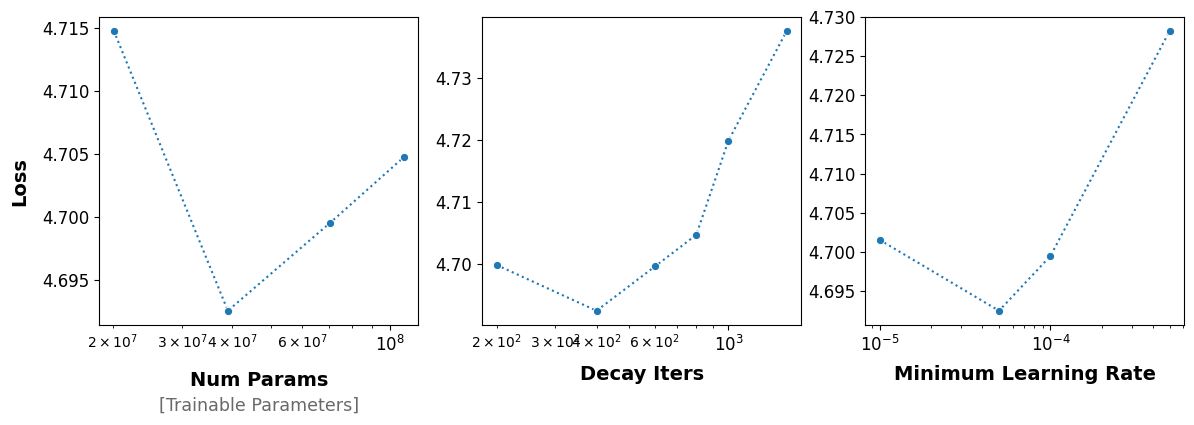

In [24]:
analv2.plotting_v2.fontsize_ticks = 12
analv2.plotting_v2.fontsize_axes_labels = 14

fig_cdp, axes = plt.subplots(1, 3, figsize=(14, 4))
ax_c, ax_d, ax_p = axes

# Set y-axis label on the left-most graph since all y-axes are the same
ax_c.text(
    -0.25, 0.4, "Loss", transform=ax_c.transAxes, rotation='vertical',
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)

# ===== Loss vs. Num Params =====

sns.lineplot(
    ax=ax_c,
    data=df_num_params, x="num_params", y="min_saved_val_loss",
    marker="o", estimator=None, linestyle=':'
)
ax_c.set_xlabel("")
ax_c.set_ylabel("")
ax_c.set_xscale("log")
ax_c.text(
    0.5, -0.18, "Num Params", transform=ax_c.transAxes,
    ha="center", va='center', fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)
ax_c.text(
    0.5, -0.28, "[Trainable Parameters]", transform=ax_c.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels * 0.9, color="dimgray"
)

# ===== Loss vs. Decay Iters =====

sns.lineplot(
    ax=ax_d,
    data=df_decay_iters, x="lr_decay_iters", y="min_saved_val_loss",
    marker="o", estimator=None, linestyle=':'
)
ax_d.set_xlabel("")
ax_d.set_ylabel("")
ax_d.set_xscale("log")
ax_d.text(
    0.5, -0.18, "Decay Iters", transform=ax_d.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)

# ===== Loss vs. Minimum Learning Rate =====

sns.lineplot(
    ax=ax_p,
    data=df_min_lr, x="min_lr", y="min_saved_val_loss",
    marker="o", estimator=None, linestyle=':'
)
ax_p.set_xlabel("")
ax_p.set_ylabel("")
ax_p.set_xscale("log")
ax_p.text(
    0.5, -0.18, "Minimum Learning Rate", transform=ax_p.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)

for ax in axes:
    ax.tick_params(axis='both', labelsize=analv2.plotting_v2.fontsize_ticks)
#     ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
# ax_p.yaxis.set_major_locator(MaxNLocator(nbins=6))

plt.show()

In [25]:
df_md_sizes = df[['model_name', 'iters_saved', 'min_saved_train_loss', 'min_saved_val_loss', 'num_train_tokens', 'num_params', 'lr_decay_iters', 'lr_warmup_iters', 'min_lr']].copy()
df_md_sizes["num_params_label"] = df_md_sizes["num_params"].map(lambda x: f"{x/1e6:.0f}M")
order = (df_md_sizes.sort_values("num_params")["num_params_label"].drop_duplicates().iloc[::-1])

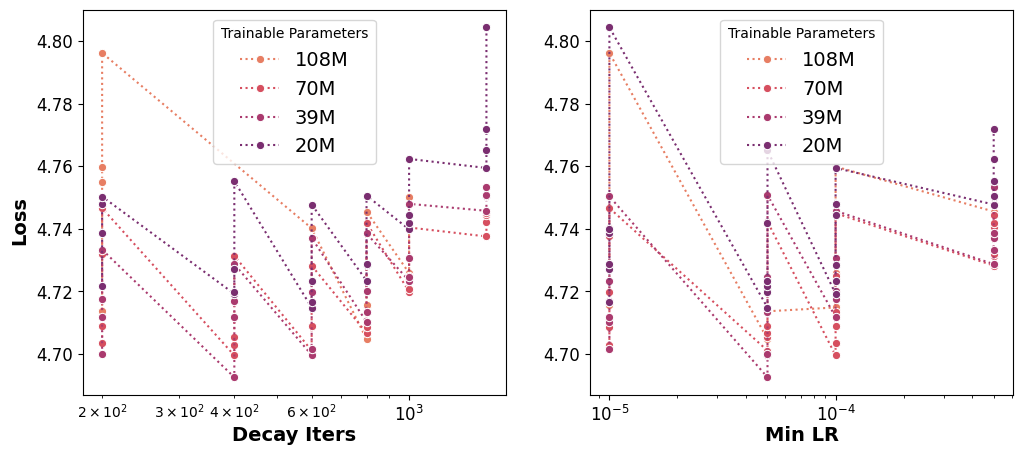

In [26]:
fig_dp_all, axes = plt.subplots(1, 2, figsize=(12, 5))
ax_di, ax_mlr = axes

sns.lineplot(
    ax=ax_di,
    data=df_md_sizes, x="lr_decay_iters", y="min_saved_val_loss", hue="num_params_label", hue_order=order,
    palette="flare", marker="o", estimator=None, linestyle=':'
)
ax_di.set_xlabel("")
ax_di.set_ylabel("")
# y-label
ax_di.text(
    -0.15, 0.4, "Loss", transform=ax_di.transAxes, rotation='vertical',
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)
# x-label
ax_di.text(
    0.5, -0.12, "Decay Iters", transform=ax_di.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)
ax_di.legend(title="Trainable Parameters", fontsize=analv2.plotting_v2.fontsize_legend)
ax_di.set_xscale("log")

sns.lineplot(
    ax=ax_mlr,
    data=df_md_sizes, x="min_lr", y="min_saved_val_loss", hue="num_params_label", hue_order=order,
    palette="flare", marker="o", estimator=None, linestyle=':'
)
ax_mlr.set_xlabel("")
ax_mlr.set_ylabel("")
# x-label
ax_mlr.text(
    0.5, -0.12, "Min LR", transform=ax_mlr.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)
ax_mlr.legend(title="Trainable Parameters", fontsize=analv2.plotting_v2.fontsize_legend)
ax_mlr.set_xscale("log")

for ax in axes:
    ax.tick_params(axis='both', labelsize=analv2.plotting_v2.fontsize_ticks)

plt.show()